In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

class NormalizationExperiments:
    """Clase para visualizar el efecto de la normalización en la función de costo ECM"""
    
    def __init__(self):
        pass
    
    def normalize_data(self, X):
        """Normaliza los datos"""
        X_mean = np.mean(X, axis=0)
        X_std = np.std(X, axis=0)
        return (X - X_mean) / X_std, X_mean, X_std
    
    def create_parameter_matrix(self, w1_min=-30, w1_max=30, w2_min=-30, w2_max=30, n_points=20):
        """Crea matriz de parámetros vectorizada"""
        w1_range = np.linspace(w1_min, w1_max, n_points)
        w2_range = np.linspace(w2_min, w2_max, n_points)
        W1, W2 = np.meshgrid(w1_range, w2_range)
        return W1, W2, np.c_[W1.ravel(), W2.ravel()]
    
    def calculate_ecm_vectorized(self, X, y, W_matrix):
        """Calcula ECM para todas las combinaciones de parámetros vectorizadamente"""
        y_pred_all = W_matrix @ X.T
        ecm_values = np.mean((y - y_pred_all) ** 2, axis=1)
        return ecm_values
    
    def _get_surface_data(self, X, y, normalize=False, w1_min=-30, w1_max=30, w2_min=-30, w2_max=30, n_points=100):
        """Método interno para obtener datos de superficie (evita repetición)"""
        X_processed = X.copy()
        if normalize:
            X_processed, _, _ = self.normalize_data(X)
        
        W1, W2, W_matrix = self.create_parameter_matrix(w1_min, w1_max, w2_min, w2_max, n_points)
        ecm_values = self.calculate_ecm_vectorized(X_processed, y, W_matrix)
        J = ecm_values.reshape(W1.shape)
        return W1, W2, J
    
    def ecm_3d_vectorized(self, X, y, normalize=False, **kwargs):
        """Función principal vectorizada"""
        W1, W2, J = self._get_surface_data(X, y, normalize, **kwargs)
        
        title = f"ECM {'CON' if normalize else 'SIN'} Normalización"
        fig = go.Figure(data=[go.Surface(z=J, x=W1, y=W2, colorscale='Blues')])
        fig.update_layout(
            title=title,
            scene=dict(
                xaxis_title='w1',
                yaxis_title='w2',
                zaxis_title='ECM'
            ),
            width=600,
            height=400
        )
        return fig
    
    def plot_3d_subplot(self, X, y, w1_range, w2_range, J_range):
        """Grafica ambas superficies en subplot 1x2"""
        params = dict(w1_min=w1_range[0], w1_max=w1_range[1], 
                     w2_min=w2_range[0], w2_max=w2_range[1], n_points=50)
        
        fig_no_norm = self.ecm_3d_vectorized(X, y, normalize=False, **params)
        fig_norm = self.ecm_3d_vectorized(X, y, normalize=True, **params)
        
        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{'type': 'scene'}, {'type': 'scene'}]],
            subplot_titles=['ECM SIN Normalización', 'ECM CON Normalización']
        )
        
        fig.add_trace(fig_no_norm.data[0], row=1, col=1)
        fig.add_trace(fig_norm.data[0], row=1, col=2)
        
        fig.update_layout(
            title='Comparación: ECM SIN vs CON Normalización',
            scene=dict(
                xaxis_title='w1', yaxis_title='w2', zaxis_title='ECM',
                zaxis=dict(range=J_range)
            ),
            scene2=dict(
                xaxis_title='w1', yaxis_title='w2', zaxis_title='ECM',
                zaxis=dict(range=J_range)
            ),
            width=1200, height=500
        )
        return fig
    
    def plot_2d_comparison(self, X, y, w1_range=(-30, 30), w2_range=(-30, 30)):
        """Grafica contornos en 2D para comparar"""
        params = dict(w1_min=w1_range[0], w1_max=w1_range[1], 
                     w2_min=w2_range[0], w2_max=w2_range[1], n_points=50)
        
        W1_no, W2_no, J_no    = self._get_surface_data(X, y, normalize=False, **params)
        W1_yes, W2_yes, J_yes = self._get_surface_data(X, y, normalize=True, **params)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        contour1 = ax1.contour(W1_no, W2_no, J_no, levels=20, cmap='viridis')
        ax1.clabel(contour1, inline=True, fontsize=8)
        ax1.set_title('ECM SIN Normalización')
        ax1.set_xlabel('w1'); ax1.set_ylabel('w2')
        ax1.grid(True, alpha=0.3)
        
        contour2 = ax2.contour(W1_yes, W2_yes, J_yes, levels=20, cmap='viridis')
        ax2.clabel(contour2, inline=True, fontsize=8)
        ax2.set_title('ECM CON Normalización')
        ax2.set_xlabel('w1'); ax2.set_ylabel('w2')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def plot_data_comparison(self, X, y):
        """Grafica datos originales vs normalizados en subplot"""
        min_x = np.min(X, axis=0)
        max_x = np.max(X, axis=0)
        X_norm, mean, std = self.normalize_data(X)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # SIN normalizar
        scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
        ax1.set_title('Datos SIN Normalización')
        ax1.set_xlabel('X₁'); ax1.set_ylabel('X₂')
        ax1.set_xlim(min_x[0] - 5, max_x[0] + 5)
        ax1.set_ylim(min_x[1] - 5, max_x[1] + 5)
        ax1.grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=ax1, label='y')
        
        # CON normalización
        scatter2 = ax2.scatter(X_norm[:, 0], X_norm[:, 1], c=y, cmap='viridis', alpha=0.6)
        ax2.set_title('Datos CON Normalización')
        ax2.set_xlabel('X₁ (normalizado)'); ax2.set_ylabel('X₂ (normalizado)')
        ax2.set_xlim(min_x[0] - 5, max_x[0] + 5)
        ax2.set_ylim(min_x[1] - 5, max_x[1] + 5)
        ax2.grid(True, alpha=0.3)
        plt.colorbar(scatter2, ax=ax2, label='y')
        
        # Agregar estadísticas
        ax1.text(0.02, 0.98, f'Media: [{np.mean(X[:, 0]):.2f}, {np.mean(X[:, 1]):.2f}]\nStd: [{np.std(X[:, 0]):.2f}, {np.std(X[:, 1]):.2f}]',
                 transform=ax1.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax2.text(0.02, 0.98, f'Media: [{np.mean(X_norm[:, 0]):.2f}, {np.mean(X_norm[:, 1]):.2f}]\nStd: [{np.std(X_norm[:, 0]):.2f}, {np.std(X_norm[:, 1]):.2f}]',
                 transform=ax2.transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        return fig
    
    def generate_data(self, w1_optimo, w2_optimo, n_samples=1000, scale1=2, scale2=20, mean1=5, mean2=5, noise_std=0.3):
        """Genera datos con parámetros específicos"""
        np.random.seed(42)
        X = np.random.randn(n_samples, 2) * [scale1, scale2] + [mean1, mean2]
        y = w1_optimo * X[:,0] + w2_optimo * X[:,1] #+ np.random.randn(n_samples) * noise_std
        
        print(f"Parámetros óptimos: w1={w1_optimo}, w2={w2_optimo}")
        print(f"X - Media: {np.mean(X, axis=0)}, Std: {np.std(X, axis=0)}")
        
        return X, y

    def run_experiment(self, w1_optimo=-10, w2_optimo=-10, scale1=2, scale2=20):
        """Ejecuta experimento completo"""
        # Generar datos
        X, y = self.generate_data(w1_optimo, w2_optimo, scale1=scale1, scale2=scale2)
        
        # Definir rangos centrados en óptimos
        margin = 100
        w1_range = (w1_optimo - margin, w1_optimo + margin)
        w2_range = (w2_optimo - margin, w2_optimo + margin)
        J_range = [0, 40_000]
        
        # Gráficos
        fig_data = self.plot_data_comparison(X, y)
        fig_3d   = self.plot_3d_subplot(X, y, w1_range, w2_range, J_range)
        fig_2d   = self.plot_2d_comparison(X, y, w1_range, w2_range)
        
        return X, y, fig_data, fig_3d, fig_2d

Parámetros óptimos: w1=-10, w2=-10
X - Media: [5.06637229 5.1139643 ], Std: [1.92224485 2.02890336]


/tmp/ipykernel_142799/1644190925.py:15: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



/tmp/ipykernel_142799/1644190925.py:17: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



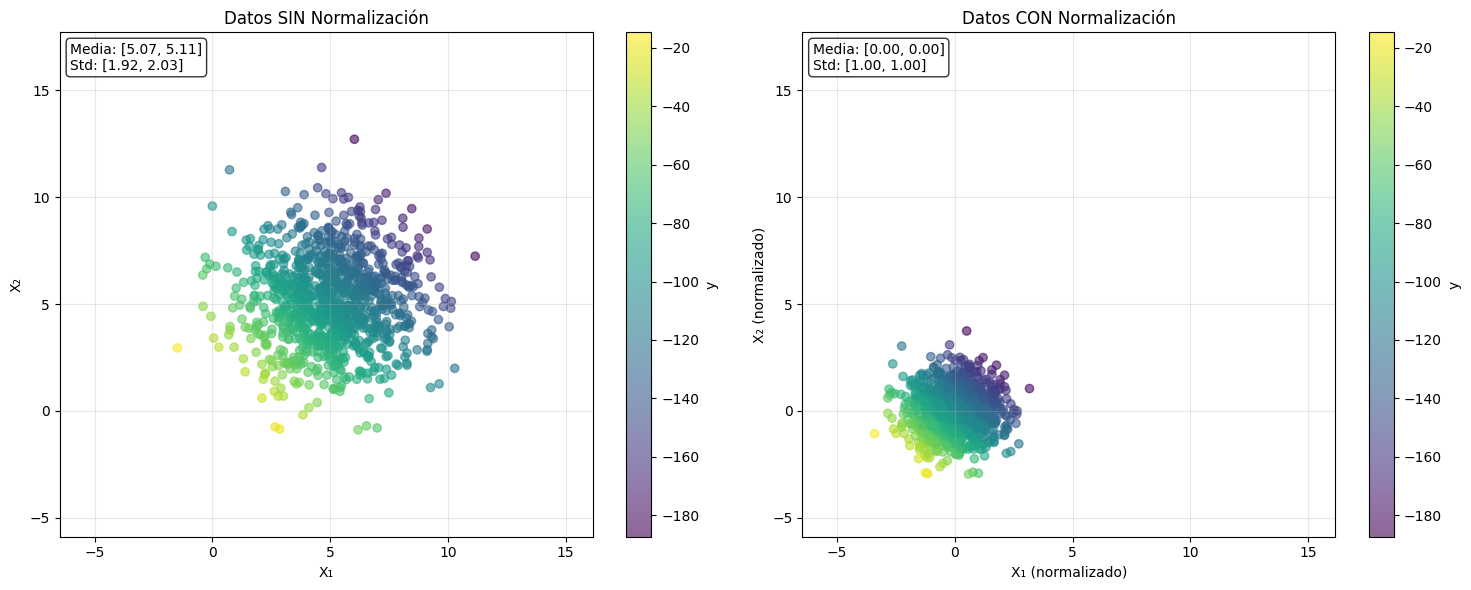

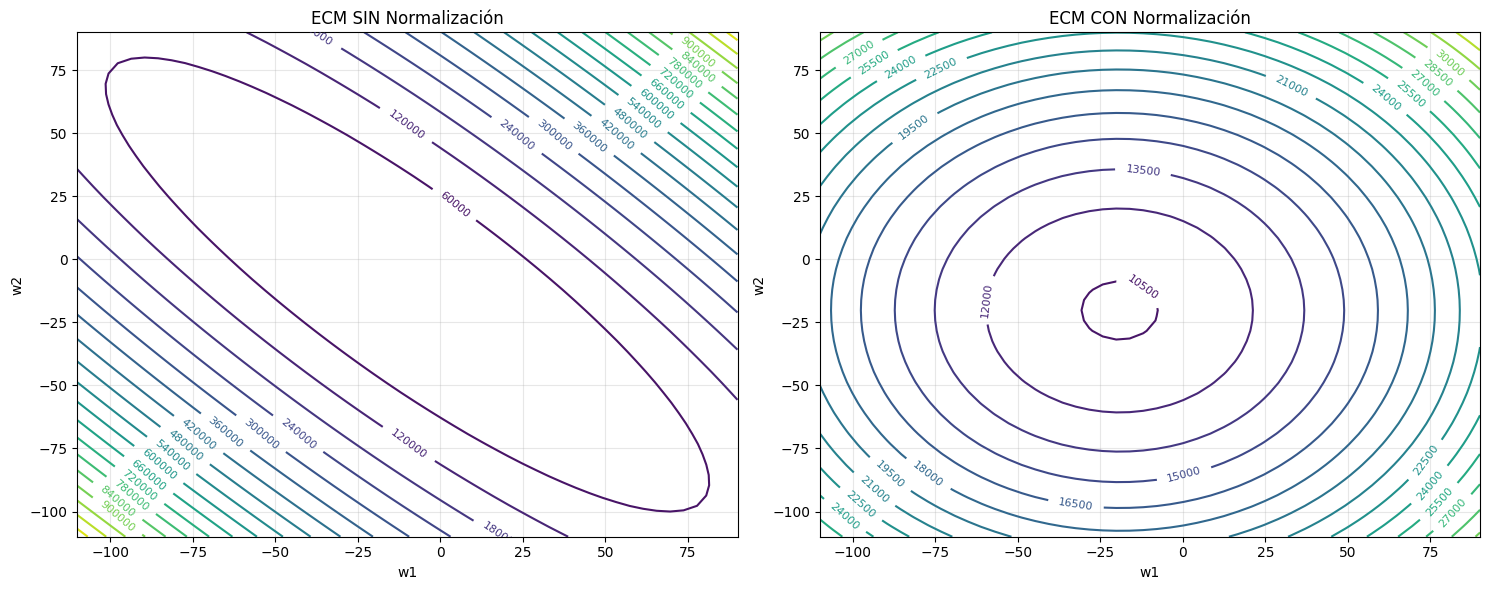

Datos normalizados - Media: [3.64236419e-16 8.21898105e-16], Std: [1. 1.]


In [2]:
# Crear instancia y ejecutar experimento
exp = NormalizationExperiments()
 
# Parámetros configurables (sin hardcode)
params = {
    'w1_optimo': -10,
    'w2_optimo': -10,
    'scale1': 2,
    'scale2': 2
}
 
# Ejecutar experimento completo (ahora retorna una sola figura con 6 gráficos)
X, y, fig_data, fig_3d, fig_2d = exp.run_experiment(**params)

fig_data.show()
fig_3d.show()
fig_2d.show()
# Mostrar la figura completa con todos los gráficos
plt.show()
 
# Información de normalización
X_norm, mean, std = exp.normalize_data(X)
print(f"Datos normalizados - Media: {np.mean(X_norm, axis=0)}, Std: {np.std(X_norm, axis=0)}")